In [1]:
import stack_tools
import importlib

In [2]:
from scipy.special import erf
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import Normalize
from matplotlib import cm
import numpy as np
from scipy.special import erfc, erfcx, log_ndtr
%matplotlib ipympl


In [3]:
no_marg = stack_tools._log_likelihood_ul(
    np.linspace(-10,10),
    np.atleast_1d([0]),
    np.atleast_1d([1]),
    np.atleast_1d([0]))
marg = stack_tools._log_likelihood_ul_nuisance(
    np.linspace(-10,10),
    np.atleast_1d([0]),
    np.atleast_1d([1]),
    np.atleast_1d([0]))

/Users/calvinleung/kko_host_paper/plot_scripts/stack_tools.py:157: RuntimeWarning: divide by zero encountered in log
  prior_vs_sigma = np.log(sigma_e[None,:] * ((sigma_data**2 + sigma_model**2)[:,None] + sigma_e[None,:]**2)**-1) # shape: (n_bursts, n_sigma_e)


/Users/calvinleung/kko_host_paper/plot_scripts/stack_tools.py:517: SyntaxWarning: invalid escape sequence '\o'
  eqn_string += f"{mxpb['x_mean']:.1f}" + '} M_\odot)'


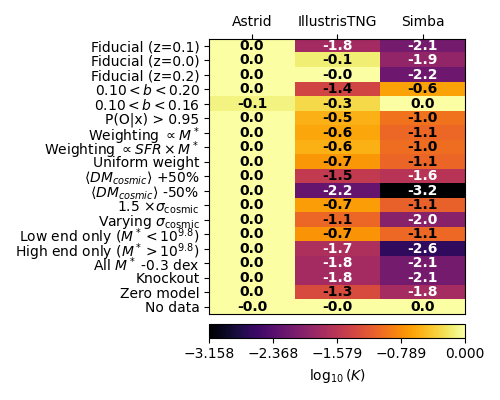

In [140]:
import pandas as pd
import dmh_tools,camels_tools
import os

models = ['Astrid','IllustrisTNG','SIMBA']
variants = [
    
    ['Fiducial (z=0.1)',('086',0.13,0.20,2,'fid0.1')],
    ['Fiducial (z=0.0)',('090',0.13,0.20,2,'fid0')],
    ['Fiducial (z=0.2)',('082',0.13,0.20,2,'fid0.2')],
    [r'$0.10 < b < 0.20$',('086',0.1,0.2,2,'lowb')],
    [r'$0.10 < b < 0.16$',('086',0.1,0.16,2,'highb')],
    [r'P(O|x) > 0.95',('086', 0.13, 0.20,2,'goldgold')],
    [r'Weighting $\propto M^*$',('086',0.13,0.2,1)],
    [r'Weighting $\propto SFR \times M^*$',('086',0.13,0.2,3)],
    ['Uniform weight' ,('086',0.13,0.20,0)],
    [r'$\langle DM_{cosmic} \rangle$ +50%',('086',0.13,0.20,2,'high_igm')],
    [r'$\langle DM_{cosmic} \rangle$ -50%',('086',0.13,0.20,2,'low_igm')],
    [r'1.5 $\times\sigma_\mathrm{cosmic}$',('086',0.13,0.20,2,'inflate_sigma_cosmic')],
    [r'Varying $\sigma_\mathrm{cosmic}$',('086',0.13,0.20,2,'varying_sigma_cosmic')],
    [r'Low end only ($M^* < 10^{9.8}$)',('086', 0.13, 0.20,2,'low')],
    [r'High end only ($M^* > 10^{9.8}$)',('086', 0.13, 0.20,2,'high')],
    [r'All $M^*$ -0.3 dex',('086', 0.13, 0.20,2,'low_mstar')],
    [r'Knockout',('086', 0.13, 0.20,2,'knockout')],
    [r'Zero model',('086', 0.13, 0.20,2,'null_model')],
    [r'No data',('086', 0.13, 0.20,2,'no_data')],
]

ROOT_PATH = os.getcwd() + '/../'
_df = pd.read_csv(os.path.join(ROOT_PATH,'data_products/remove_clusters_lowdm_edgeon.csv'))
_df.set_index('name',inplace=True)
keep = dmh_tools.not_clusters(_df) * dmh_tools.not_edge_on(_df) * dmh_tools.not_scattered(_df) * dmh_tools.not_elliptical(_df) * dmh_tools.not_low_dm(_df) * dmh_tools.not_dwarf(_df)
df = _df[keep]
plot_mstar = df['published_M*']
plot_dm = df['DM_host_restframe']
plot_dmerr = dmh_tools.sigma_tot(df)
keep = dmh_tools.not_clusters(df) * dmh_tools.not_edge_on(df) * dmh_tools.not_scattered(df) * dmh_tools.not_elliptical(df) * dmh_tools.not_low_dm(df) * dmh_tools.not_dwarf(df)

sigma_cbm_arr = np.linspace(1,100,num = 110)  #np.linspace(1,100,num = 1)
dm_cbm_arr = np.linspace(0,400,num = 80) #np.linspace(0,200, num = 1)
ll_per_variant_model_burst = np.zeros((len(variants),3,len(df),len(sigma_cbm_arr),len(dm_cbm_arr)))
ll_per_variant = np.zeros((3,len(variants)))

import importlib
importlib.reload(stack_tools)

for iivariant,(variant_name,params) in enumerate(variants):
    for iimodel,model in enumerate(models):
        keep = dmh_tools.not_low_dm(df) * dmh_tools.not_scattered(df) * dmh_tools.not_clusters(df) * dmh_tools.not_edge_on(df) * dmh_tools.not_dwarf(df) * np.array([name not in ['FRB20220319D', 'FRB20210807D'] for name in df.index])
        # analysis perturbations
        vary_igm_factor = 0
        model_mult = 1
        data_err_mult = 1
        mstar_bias_dex = 0.0    
        try:
            (snap_id, b_min, b_max, iiweight,variant) = params
        except:
            (snap_id, b_min, b_max, iiweight) = params
        if variant == 'low':
            keep = df['published_M*'] < 9.8
        elif variant == 'high':
            keep = df['published_M*'] >= 9.8
        elif variant == 'low_igm':
            vary_igm_factor = -0.5
        elif variant == 'high_igm':
            vary_igm_factor = 0.5
        elif variant == 'goldgold':
            keep = keep * np.isnan(df['primary_P_Ox']) + (df['primary_P_Ox'] > 0.95)
        elif variant == 'knockout':
            keep = keep * np.array([name not in ['FRB20220319D', 'FRB20210807D'] for name in df.index])
        elif variant == 'null_model':
            model_mult = 0
        elif variant == 'varying_sigma_cosmic':
            if model == 'SIMBA':
                data_err_mult = 0.8
            if model == 'Astrid':
                data_err_mult = 1.5
            if model == 'IllustrisTNG':
                data_err_mult = 1.0
        elif variant == 'inflate_sigma_cosmic':
            data_err_mult = 1.5
        elif variant == 'low_mstar': # if we overestimate our stellar masses
            mstar_bias_dex = -0.3
        elif variant == 'no_data':
            data_err_mult = 100
        redshift_str = f"z = {camels_tools.CAMELS_REDSHIFTS[snap_id]:.2f}"
        snap_z = camels_tools.CAMELS_REDSHIFTS[snap_id]
        stack_path = f'/Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/{model}_1P_3_0_snap{snap_id}_haloDM' + f'_bminmax={b_min:.2f}_{b_max:.2f}.h5'
        results = camels_tools.from_file(stack_path)
        results['weighted_mean'] *= model_mult
        ll_per_variant_model_burst[iivariant,iimodel,keep] = stack_tools.log_likelihood_hp_gauss(
            ms = (plot_mstar * 10**(mstar_bias_dex))[keep],
            dm = ((plot_dm + vary_igm_factor * df['dm_igm']))[keep],
            dm_err = ((plot_dmerr * data_err_mult))[keep],
            res=results,
            sigma_cbm_arr = sigma_cbm_arr,
            dm_cbm_arr = dm_cbm_arr,
            weight_index = iiweight)
    prior = 1/sigma_cbm_arr[:,None] * (dm_cbm_arr[None,:] > (3* sigma_cbm_arr[:,None]))
    ll_per_variant[:,iivariant] = stack_tools.marginalize_ll_hp(
                                        ll_per_variant_model_burst[iivariant],
                                        prior,
                                        dm_cbm_arr,
                                        sigma_cbm_arr,
                                    )
fig = plt.figure(figsize = (5,4))
#plt.title(r'Bayes')
stack_tools.plot_fig2(fig,plt.gca(),ll_per_variant * np.log10(np.e), cmap = 'inferno',xnames = ['Astrid','IllustrisTNG','Simba'], 
    ynames = np.array([v[0] for v in variants]), cbar_label = r'$\log_{10}(K)$',
    #out_file = os.path.join(ROOT_PATH,'figures/model_selection_ul.pdf')
                     )
plt.tight_layout()

In [141]:
ll_per_variant_model_burst.shape

(19, 3, 22, 110, 80)

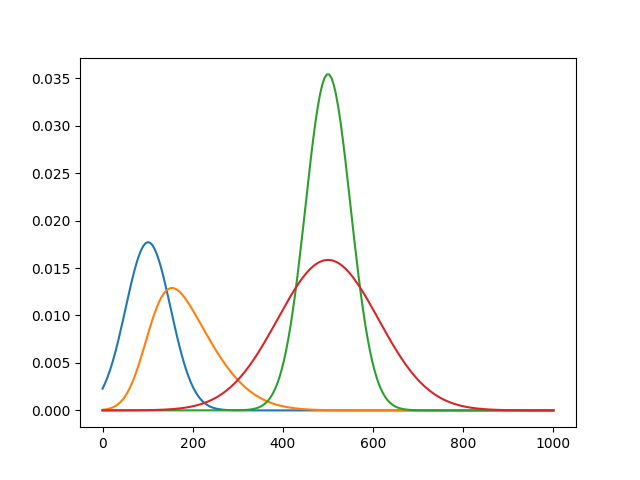

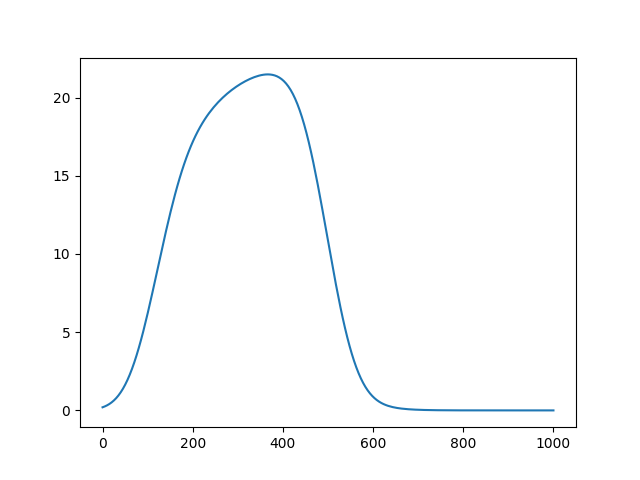

In [142]:
dm_test = np.linspace(0,1000,num = 200)
test= np.array(list(map(lambda x: stack_tools.log_likelihood_mgaussian(
            dm_host_restframe = x,
            sigma_i = 50,
            dm_model = 100,
            sigma_cbm_arr = sigma_cbm_arr,
            dm_cbm_arr = dm_cbm_arr),
    dm_test,
)))

ans = np.zeros(200)
for ii,_test in enumerate(test):
    ans[ii] = stack_tools.marginalize_ll_hp(_test,prior = prior, dm_cbm_arr = dm_cbm_arr, sigma_cbm_arr = sigma_cbm_arr).squeeze()

plt.figure()
plt.plot(dm_test,np.exp(test[:,0,0]))
plt.plot(dm_test,np.exp(test[:,-1,0]))
plt.plot(dm_test,np.exp(test[:,0,-1]))
plt.plot(dm_test,np.exp(test[:,-1,-1]))

plt.figure()
plt.plot(dm_test,np.exp(ans))

In [143]:
ll_per_variant_model_burst_test = np.zeros((200,22,30,50))
for ii,dm_model in enumerate(np.linspace(0,200,num = 200)):
    results['weighted_mean'] *= 0
    results['weighted_mean'] += dm_model
    ll_per_variant_model_burst_test[ii] = stack_tools.log_likelihood_hp_gauss(
        ms = (plot_mstar * 10**(mstar_bias_dex)),
        dm = ((plot_dm + vary_igm_factor * df['dm_igm'])),
        dm_err = ((plot_dmerr * data_err_mult)),
        res=results,
        sigma_cbm_arr = sigma_cbm_arr,
        dm_cbm_arr = dm_cbm_arr,
        weight_index = 2
    )

ValueError: could not broadcast input array from shape (22,110,80) into shape (22,30,50)

In [144]:
def find_argmax(x,y,xy):
    shape = xy.shape
    iy,ix = np.unravel_index(np.argmax(xy.flat),shape)
    return x[ix],y[iy]

/var/folders/2v/13b457dx6qn34sd445522vnc0000gp/T/ipykernel_25536/1191332989.py:4: RuntimeWarning: divide by zero encountered in log
  ans = np.log(prior) + np.sum(ll_per_variant_model_burst,axis = 2)[0,iimodel]


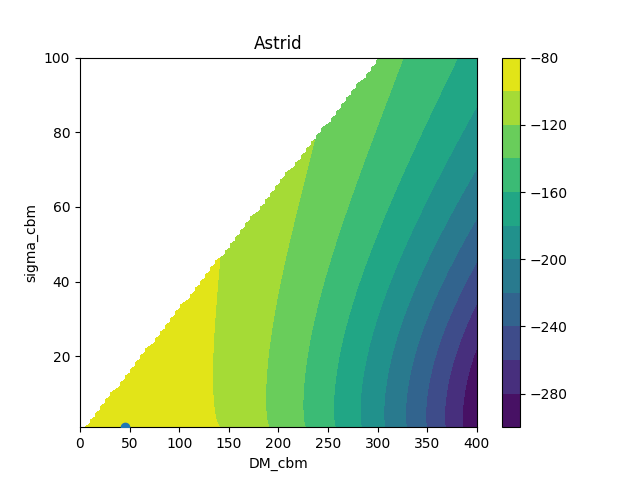

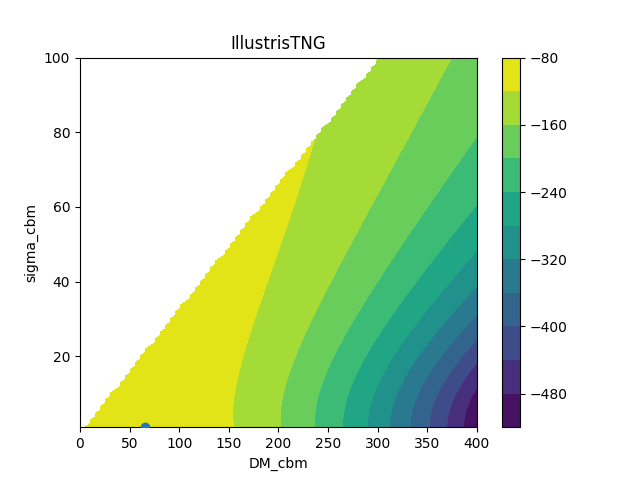

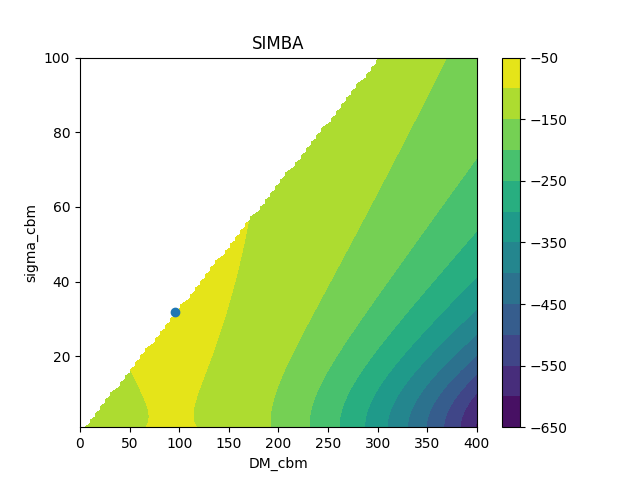

In [145]:

for iimodel,model in enumerate(models):
    plt.figure()
    plt.title(model)
    ans = np.log(prior) + np.sum(ll_per_variant_model_burst,axis = 2)[0,iimodel]
    x,y = find_argmax(dm_cbm_arr,sigma_cbm_arr,ans)
    plt.scatter(x,y,zorder = 10)
    plt.contourf(dm_cbm_arr,sigma_cbm_arr,ans,levels = 10)
    plt.xlabel('DM_cbm')
    plt.ylabel('sigma_cbm')
    plt.colorbar()


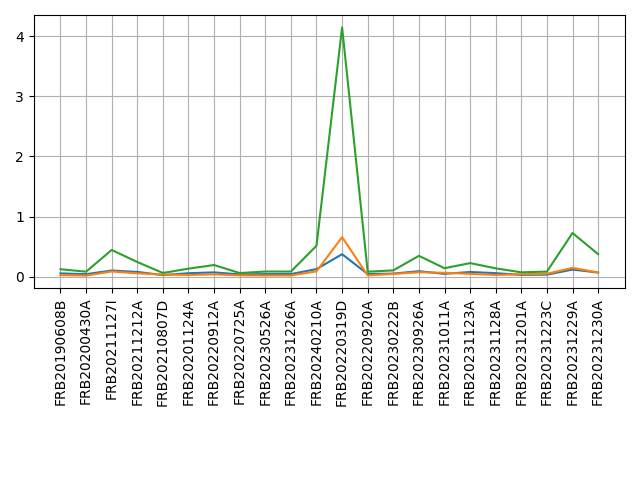

In [117]:
plt.figure()
plt.plot(df.index,(np.max(np.abs(ll_per_variant_model_burst[3] - ll_per_variant_model_burst[0]),axis = (-2,-1))).T)
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.subplots_adjust(bottom=0.4)

In [35]:
np.sum(np.exp(ll_per_variant_model_burst[3]) - ll_per_variant_model_burst[0]

SyntaxError: incomplete input (1883278681.py, line 1)

# Check the integral

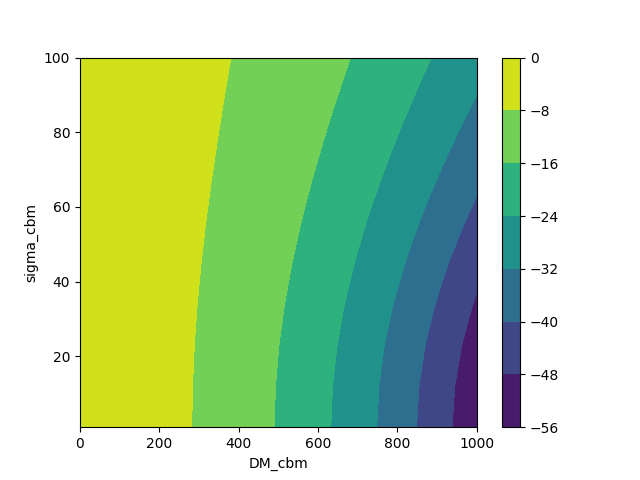

In [146]:
sigma_cbm_arr = np.linspace(1,100,num = 10)
dm_cbm_arr = np.linspace(0,1000)
ans = stack_tools.log_likelihood_mgaussian(dm_host_restframe = 100, sigma_i = 100, 
                                                  dm_model = 100,sigma_cbm_arr = sigma_cbm_arr, 
                                                  dm_cbm_arr=dm_cbm_arr).squeeze()
plt.figure()
plt.contourf(dm_cbm_arr,sigma_cbm_arr,ans)
plt.xlabel('DM_cbm')
plt.ylabel('sigma_cbm')
plt.colorbar()


In [178]:

numerical_integral(a = 100,b = 10,w = (1/80)**2, S = (1/100)**2, mu = np.log(10))

8111.204652077846

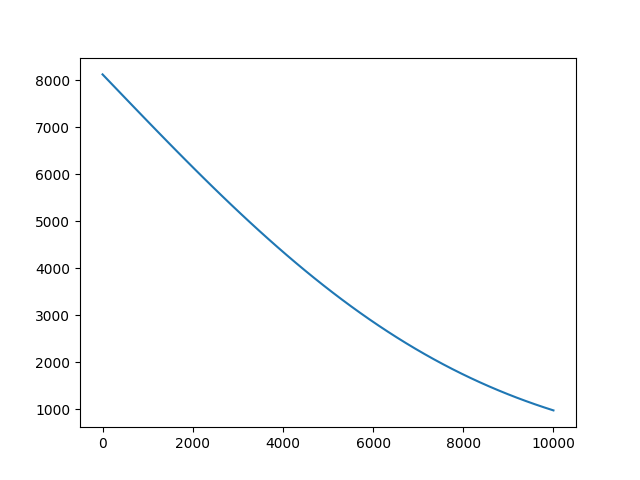

In [181]:
plt.figure()
plt.plot(np.linspace(0,10000),
         np.array([numerical_integral(a = 100,b = x,w = (1/80)**2, S = (1/100)**2, mu = np.log(10)) for x in np.linspace(0,10000)]))

In [148]:
import numpy as np
from scipy.integrate import quad
from scipy.special import erf
import warnings

def saddle_point_integral(a, b, w, S, mu, tol=1e-12, max_iter=50):
    """
    Compute integral of exp(-0.5*w^2*(a-b-c)^2) * exp(-S^2*(ln(c)-mu)^2) from 0 to inf
    using saddle point approximation.
    
    Parameters:
    -----------
    a, b : float
        Parameters in (a-b-c)^2 term
    w : float
        Width parameter for Gaussian term
    S : array_like, shape (n_S,) or float
        Width parameter(s) for log-normal term
    mu : array_like, shape (n_mu,) or float
        Mean parameter(s) for log-normal term
    tol : float
        Convergence tolerance for Newton's method
    max_iter : int
        Maximum iterations for Newton's method
    
    Returns:
    --------
    ndarray : Approximation of the integral, shape (n_S, n_mu) if both S and mu are arrays,
              shape (n_S,) if only S is array, shape (n_mu,) if only mu is array,
              or float if both are scalars
    """
    # Convert to numpy arrays
    S = np.asarray(S)
    mu = np.asarray(mu)
    
    # Determine output shape
    if S.ndim == 0 and mu.ndim == 0:
        # Both scalars
        return _saddle_point_scalar(a, b, w, S.item(), mu.item(), tol, max_iter)
    elif S.ndim == 0:
        # S scalar, mu array
        S_vals = np.full(mu.shape, S.item())
        mu_vals = mu
        output_shape = mu.shape
    elif mu.ndim == 0:
        # S array, mu scalar  
        S_vals = S
        mu_vals = np.full(S.shape, mu.item())
        output_shape = S.shape
    else:
        # Both arrays - create meshgrid
        S_grid, mu_grid = np.meshgrid(S, mu, indexing='ij')
        S_vals = S_grid.ravel()
        mu_vals = mu_grid.ravel()
        output_shape = (len(S), len(mu))
    
    # Vectorized computation
    results = _saddle_point_vectorized(a, b, w, S_vals, mu_vals, tol, max_iter)
    
    return results.reshape(output_shape)

def _saddle_point_scalar(a, b, w, S, mu, tol, max_iter):
    """Scalar version of saddle point computation"""
    # Initial guess: mode of log-normal component
    c0 = np.exp(mu)
    
    # Newton's method to find saddle point
    for i in range(max_iter):
        # Function: G(c0) = 2*S^2*(ln(c0)-mu) - w^2*c0*(a-b-c0) - 1
        G = 2*S**2*(np.log(c0) - mu) - w**2*c0*(a - b - c0) - 1
        
        # Derivative: G'(c0) = 2*S^2/c0 - w^2*(a-b-2*c0)
        Gprime = 2*S**2/c0 - w**2*(a - b - 2*c0)
        
        # Newton update
        c0_new = c0 - G/Gprime
        
        # Check convergence
        if abs(c0_new - c0) < tol:
            c0 = c0_new
            break
        c0 = c0_new
    else:
        warnings.warn(f"Newton's method did not converge after {max_iter} iterations")
    
    # Compute function value at saddle point
    u0 = np.log(c0)
    f_u0 = -0.5*w**2*(a - b - c0)**2 - S**2*(u0 - mu)**2 + u0
    
    # Compute second derivative at saddle point
    f_double_prime = w**2*c0*(a - b - 2*c0) - 2*S**2
    
    # Check validity condition
    if f_double_prime >= 0:
        warnings.warn("Second derivative is non-negative; approximation may be invalid")
    
    # Saddle point approximation
    result = np.exp(f_u0) * np.sqrt(2*np.pi / (-f_double_prime))
    
    return result

def _saddle_point_vectorized(a, b, w, S_vals, mu_vals, tol, max_iter):
    """Vectorized saddle point computation"""
    n = len(S_vals)
    
    # Initial guess: mode of log-normal component
    c0 = np.exp(mu_vals)
    
    # Track convergence
    converged = np.zeros(n, dtype=bool)
    
    # Newton's method to find saddle point (vectorized)
    for i in range(max_iter):
        # Function: G(c0) = 2*S^2*(ln(c0)-mu) - w^2*c0*(a-b-c0) - 1
        G = 2*S_vals**2*(np.log(c0) - mu_vals) - w**2*c0*(a - b - c0) - 1
        
        # Derivative: G'(c0) = 2*S^2/c0 - w^2*(a-b-2*c0)
        Gprime = 2*S_vals**2/c0 - w**2*(a - b - 2*c0)
        
        # Newton update
        c0_new = c0 - G/Gprime
        
        # Check convergence
        not_converged = ~converged
        newly_converged = (np.abs(c0_new - c0) < tol) & not_converged
        converged |= newly_converged
        
        # Update only non-converged values
        c0 = np.where(converged, c0, c0_new)
        
        # Early exit if all converged
        if np.all(converged):
            break
    
    if not np.all(converged):
        n_unconverged = np.sum(~converged)
        warnings.warn(f"Newton's method did not converge for {n_unconverged}/{n} points after {max_iter} iterations")
    
    # Compute function value at saddle point
    u0 = np.log(c0)
    f_u0 = -0.5*w**2*(a - b - c0)**2 - S_vals**2*(u0 - mu_vals)**2 + u0
    
    # Compute second derivative at saddle point
    f_double_prime = w**2*c0*(a - b - 2*c0) - 2*S_vals**2
    
    # Check validity condition
    invalid = f_double_prime >= 0
    if np.any(invalid):
        n_invalid = np.sum(invalid)
        warnings.warn(f"Second derivative is non-negative for {n_invalid}/{n} points; approximation may be invalid")
    
    # Saddle point approximation (handle invalid points)
    with np.errstate(invalid='ignore'):
        result = np.exp(f_u0) * np.sqrt(2*np.pi / (-f_double_prime))
        result = np.where(invalid, np.nan, result)
    
    return result

def exact_integral_w_large(a, b, w, S, mu):
    """Exact result when w^2 >> S^2 (Gaussian dominates)"""
    # Approximate saddle point when w is large
    c_approx = a - b
    if c_approx <= 0:
        return 0.0
    
    # Leading order approximation
    correction = 1/(w**2*c_approx) + 2*S**2*(np.log(c_approx) - mu)/(w**2*c_approx)
    c0 = c_approx + correction
    
    # Gaussian integral with log-normal weight at saddle point
    prefactor = np.exp(-S**2*(np.log(c0) - mu)**2) * c0
    gaussian_part = np.sqrt(np.pi/2) / w
    
    return prefactor * gaussian_part

def exact_integral_S_large(a, b, w, S, mu):
    """Exact result when S^2 >> w^2 (log-normal dominates)"""
    # Mode of log-normal with correction
    c0 = np.exp(mu + 1/(2*S**2))
    
    # Log-normal integral with Gaussian weight at mode
    prefactor = np.exp(-0.5*w**2*(a - b - c0)**2)
    lognormal_part = np.sqrt(np.pi) / S * np.exp(mu + 1/(4*S**2))
    
    return prefactor * lognormal_part

def numerical_integral(a, b, w, S, mu):
    """Numerical integration for comparison"""
    def integrand(c):
        if c <= 0:
            return 0
        return np.exp(-0.5*w**2*(a - b - c)**2 - S**2*(np.log(c) - mu)**2)
    
    result, _ = quad(integrand, 0, np.inf, limit=100)
    return result

def run_tests():
    """Test the saddle point approximation against known limits"""
    print("Testing Saddle Point Approximation")
    print("=" * 50)
    
    # Test parameters
    a, b = 5.0, 2.0
    
    # Test 1: Large w^2 limit (scalar)
    print("\nTest 1: Large w^2 limit (w=10, S=0.5, mu=1.0)")
    w, S, mu = 10.0, 0.5, 1.0
    
    saddle_result = saddle_point_integral(a, b, w, S, mu)
    limit_result = exact_integral_w_large(a, b, w, S, mu)
    numerical_result = numerical_integral(a, b, w, S, mu)
    
    print(f"Saddle point:     {saddle_result:.6f}")
    print(f"Large w limit:    {limit_result:.6f}")
    print(f"Numerical:        {numerical_result:.6f}")
    print(f"Saddle vs Limit:  {abs(saddle_result - limit_result)/limit_result*100:.3f}% error")
    print(f"Saddle vs Numerical: {abs(saddle_result - numerical_result)/numerical_result*100:.3f}% error")
    
    # Test 2: Large S^2 limit (scalar)
    print("\nTest 2: Large S^2 limit (w=0.5, S=10, mu=1.0)")
    w, S, mu = 0.5, 10.0, 1.0
    
    saddle_result = saddle_point_integral(a, b, w, S, mu)
    limit_result = exact_integral_S_large(a, b, w, S, mu)
    numerical_result = numerical_integral(a, b, w, S, mu)
    
    print(f"Saddle point:     {saddle_result:.6f}")
    print(f"Large S limit:    {limit_result:.6f}")  
    print(f"Numerical:        {numerical_result:.6f}")
    print(f"Saddle vs Limit:  {abs(saddle_result - limit_result)/limit_result*100:.3f}% error")
    print(f"Saddle vs Numerical: {abs(saddle_result - numerical_result)/numerical_result*100:.3f}% error")
    
    # Test 3: Vectorized - array of S values
    print("\nTest 3: Vectorized S array (w=2, S=[0.5,1,2,5], mu=1.0)")
    w = 2.0
    S_array = np.array([0.5, 1.0, 2.0, 5.0])
    mu = 1.0
    
    saddle_results = saddle_point_integral(a, b, w, S_array, mu)
    print(f"Results shape: {saddle_results.shape}")
    for i, (S_val, result) in enumerate(zip(S_array, saddle_results)):
        numerical = numerical_integral(a, b, w, S_val, mu)
        error = abs(result - numerical)/numerical*100
        print(f"  S={S_val:.1f}: saddle={result:.6f}, numerical={numerical:.6f}, error={error:.2f}%")
    
    # Test 4: Vectorized - array of mu values  
    print("\nTest 4: Vectorized mu array (w=2, S=1.5, mu=[0,0.5,1,1.5])")
    w = 2.0
    S = 1.5
    mu_array = np.array([0.0, 0.5, 1.0, 1.5])
    
    saddle_results = saddle_point_integral(a, b, w, S, mu_array)
    print(f"Results shape: {saddle_results.shape}")
    for i, (mu_val, result) in enumerate(zip(mu_array, saddle_results)):
        numerical = numerical_integral(a, b, w, S, mu_val)
        error = abs(result - numerical)/numerical*100
        print(f"  mu={mu_val:.1f}: saddle={result:.6f}, numerical={numerical:.6f}, error={error:.2f}%")
    
    # Test 5: Vectorized - 2D grid (S array x mu array)
    print("\nTest 5: Vectorized 2D grid (w=2, S=[1,2,3], mu=[0.5,1.0,1.5])")
    w = 2.0
    S_array = np.array([1.0, 2.0, 3.0])
    mu_array = np.array([0.5, 1.0, 1.5])
    
    saddle_results = saddle_point_integral(a, b, w, S_array, mu_array)
    print(f"Results shape: {saddle_results.shape}")
    print("Saddle point results:")
    print(saddle_results)
    
    # Compare with numerical for a few points
    print("\nSpot checks against numerical integration:")
    for i in range(len(S_array)):
        for j in range(len(mu_array)):
            numerical = numerical_integral(a, b, w, S_array[i], mu_array[j])
            saddle = saddle_results[i, j]
            error = abs(saddle - numerical)/numerical*100
            print(f"  S={S_array[i]:.1f}, mu={mu_array[j]:.1f}: error={error:.2f}%")
    
    # Test 6: Performance test
    print("\nTest 6: Performance comparison")
    w = 2.0
    S_large = np.linspace(0.5, 5.0, 50)
    mu_large = np.linspace(0.0, 2.0, 40)
    
    import time
    start = time.time()
    results_vectorized = saddle_point_integral(a, b, w, S_large, mu_large)
    vectorized_time = time.time() - start
    
    print(f"Vectorized computation: {results_vectorized.shape} results in {vectorized_time:.4f} seconds")
    print(f"Average time per evaluation: {vectorized_time/(50*40)*1000:.3f} ms")

if __name__ == "__main__":
    run_tests()

Testing Saddle Point Approximation

Test 1: Large w^2 limit (w=10, S=0.5, mu=1.0)
Saddle point:     0.249715
Large w limit:    0.375497
Numerical:        0.249992
Saddle vs Limit:  33.497% error
Saddle vs Numerical: 0.111% error

Test 2: Large S^2 limit (w=0.5, S=10, mu=1.0)
Saddle point:     0.476722
Large S limit:    0.478689
Numerical:        0.476703
Saddle vs Limit:  0.411% error
Saddle vs Numerical: 0.004% error

Test 3: Vectorized S array (w=2, S=[0.5,1,2,5], mu=1.0)
Results shape: (4,)
  S=0.5: saddle=1.211302, numerical=1.241847, error=2.46%
  S=1.0: saddle=1.183340, numerical=1.209067, error=2.13%
  S=2.0: saddle=1.084600, numerical=1.097768, error=1.20%
  S=5.0: saddle=0.717217, numerical=0.716731, error=0.07%

Test 4: Vectorized mu array (w=2, S=1.5, mu=[0,0.5,1,1.5])
Results shape: (4,)
  mu=0.0: saddle=0.112630, numerical=0.115708, error=2.66%
  mu=0.5: saddle=0.581032, numerical=0.593252, error=2.06%
  mu=1.0: saddle=1.139795, numerical=1.159211, error=1.67%
  mu=1.5: sa

/var/folders/2v/13b457dx6qn34sd445522vnc0000gp/T/ipykernel_25536/3895638297.py:115: RuntimeWarning: invalid value encountered in log
  G = 2*S_vals**2*(np.log(c0) - mu_vals) - w**2*c0*(a - b - c0) - 1
/var/folders/2v/13b457dx6qn34sd445522vnc0000gp/T/ipykernel_25536/3895638297.py:137: UserWarning: Newton's method did not converge for 59/2000 points after 50 iterations
  warnings.warn(f"Newton's method did not converge for {n_unconverged}/{n} points after {max_iter} iterations")


In [199]:
ll_sweep.shape


(50, 2, 3)